## import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# EDA

## User data

In [10]:
# File path
path = "../data/user_coop.csv"

# Columns to convert to string
data_types = [
    "userid",
    "activated",
    "adminid",
    "sex",
    "foreigner",
]

# Columns to convert to datetime
date_columns = [
    "birthdate",
    "registedtime",
    "last_login",
]

# Load CSV
user_df = pd.read_csv(path)
user_df = user_df.drop(columns=["cl_expiredate", "dl_expiredate", "motodl_number", "howtoknown", "uploadedtime", "updatedtime"], errors="ignore")

# Convert date columns safely
for date_col in date_columns:
    if date_col in user_df.columns:
        user_df[date_col] = pd.to_datetime(user_df[date_col], errors="coerce")

# Convert data type columns to string safely
for col in data_types:
    if col in user_df.columns:
        user_df[col] = user_df[col].astype(object)

# Display summary info
user_df.info()
user_df.head(20)


/var/folders/cj/gfy7l4ys0m7gd6jgx2hnycl40000gn/T/ipykernel_11253/3979291643.py:21: DtypeWarning:

Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199160 entries, 0 to 199159
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   userid        199160 non-null  object        
 1   activated     199160 non-null  object        
 2   adminid       199160 non-null  object        
 3   sex           44562 non-null   object        
 4   foreigner     199160 non-null  object        
 5   birthdate     50468 non-null   datetime64[ns]
 6   registedtime  197483 non-null  datetime64[ns]
 7   last_login    8348 non-null    datetime64[ns]
dtypes: datetime64[ns](3), object(5)
memory usage: 12.2+ MB


,userid,activated,adminid,sex,foreigner,birthdate,registedtime,last_login
0,1,TRUE,0,NaN,0,1901-03-01 00:00:56,2017-06-28 10:31:41,2018-01-20 09:55:08
1,2,TRUE,1,male,0,1982-12-30 00:00:00,2017-06-29 08:27:32,2019-02-11 08:51:55
2,3,TRUE,0,NaN,0,NaT,2017-02-13 23:06:21,NaT
3,4,TRUE,0,NaN,0,NaT,2017-02-13 23:06:21,NaT
4,5,TRUE,0,male,0,1991-02-25 00:00:00,2017-06-28 10:38:36,2017-05-18 02:52:31
5,6,SUSPEND,0,NaN,0,1900-03-01 07:00:00,2017-04-03 09:42:50,NaT
6,26,TRUE,0,NaN,0,1900-04-01 00:00:00,2016-09-01 00:00:00,NaT
7,32,TRUE,1,male,0,1988-11-11 00:00:00,2016-09-01 00:00:00,2018-04-03 04:59:16
8,33,TRUE,1,male,0,1979-10-25 00:00:00,2016-09-01 00:00:00,2017-11-23 02:36:52
9,34,TRUE,0,NaN,0,NaT,2016-09-01 00:00:00,NaT


In [11]:
user_df.isna().sum()

userid               0
activated            0
adminid              0
sex             154598
foreigner            0
birthdate       148692
registedtime      1677
last_login      190812
dtype: int64

### activated

In [12]:
user_df.activated.value_counts()

activated
FALSE          144620
TRUE            32409
REJECT          19129
DEACTIVATED      1556
SUSPEND          1446
Name: count, dtype: int64

### sex

In [13]:
user_df.sex.value_counts()

sex
male         29291
female       15232
unspecify       35
ชาย              2
male             1
Male             1
Name: count, dtype: int64

In [14]:
# Define normalization mapping
mapping = {
    "male": "male",
    "ชาย": "male",
    "man": "male",
    "m": "male",
    "female": "female",
    "หญิง": "female",
    "woman": "female",
    "f": "female",
    "unspecify": "unspecified",
    "unspecified": "unspecified",
    "unknown": "unspecified",
    "na": "unspecified",
    "n/a": "unspecified",
}

# Normalize text
user_df["sex"] = (
    user_df["sex"]
    .str.strip()
    .str.lower()
    .map(mapping)
    .fillna("unspecified")  # Handle any unmapped values
)
user_df.sex.value_counts()

sex
unspecified    154633
male            29295
female          15232
Name: count, dtype: int64

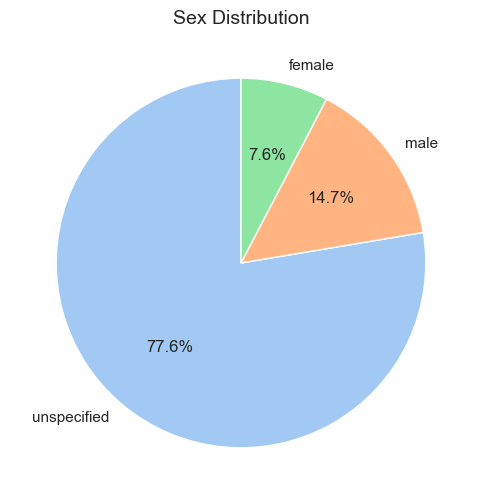

In [15]:
sex_counts = user_df["sex"].value_counts()

# Apply Seaborn theme
sns.set_theme(style="whitegrid")

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    sex_counts,
    labels=sex_counts.index,
    autopct="%1.1f%%",   # show percentage
    startangle=90,       # rotate start
    colors=sns.color_palette("pastel")  # pretty colors
)

plt.title("Sex Distribution", fontsize=14)
plt.show()

### birthdate

<Axes: xlabel='birthdate', ylabel='Count'>

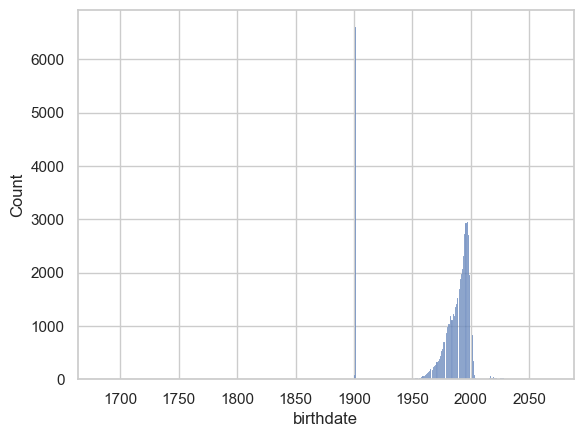

In [16]:
sns.histplot(user_df['birthdate'].dt.year.astype('Int64'))

<Axes: xlabel='birthdate', ylabel='Count'>

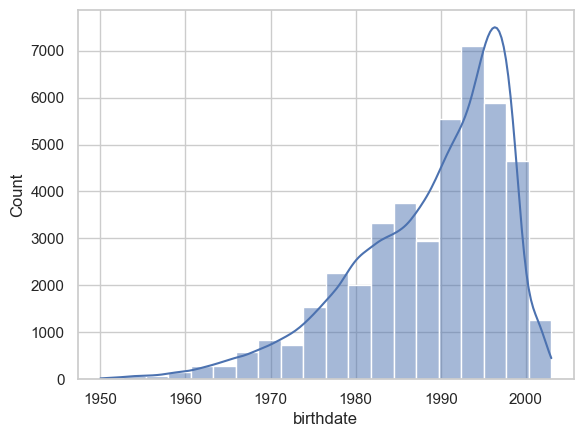

In [17]:
sns.histplot(
    user_df.loc[
        (user_df["birthdate"] > "1950-01-01") & 
        (user_df["birthdate"] < "2004-01-01"), 
        "birthdate"
    ].dt.year.astype("Int64"),
    bins=20,
    kde=True
)

In [18]:
user_df.loc[
        (user_df["birthdate"] < "1950-01-01") | 
        (user_df["birthdate"] > "2004-01-01"),
        "birthdate"
    ] = np.nan

<Axes: xlabel='birthdate', ylabel='Count'>

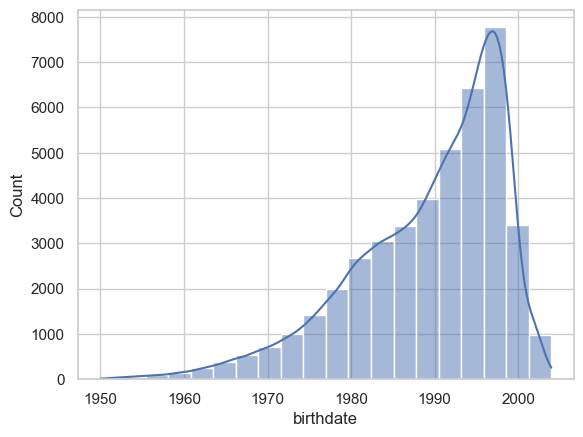

In [19]:
sns.histplot(user_df["birthdate"],
    bins=20,
    kde=True
)

In [20]:
# Define the date range
start_date = pd.Timestamp("1950-01-01")
end_date = pd.Timestamp("2004-01-01")

# Number of missing values
n_missing = user_df["birthdate"].isna().sum()

# Generate left-skewed random numbers using Beta distribution
# alpha < beta => left skew (more early dates)
alpha, beta = 5, 1.5
rand = np.random.beta(alpha, beta, n_missing)

# Convert random numbers [0,1] to timestamps
rand_seconds = rand * (end_date.value - start_date.value)
rand_dates = pd.to_datetime(start_date.value + rand_seconds.astype(np.int64))

# Replace NaT with generated dates
user_df.loc[user_df["birthdate"].isna(), "birthdate"] = rand_dates


<Axes: xlabel='birthdate', ylabel='Count'>

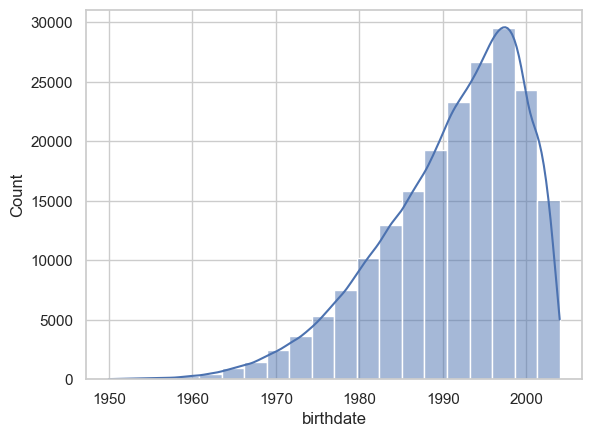

In [21]:
sns.histplot(user_df["birthdate"],
    bins=20,
    kde=True
)

### name

In [22]:
from faker import Faker
fake = Faker('th_TH')
fake.name()

'สิริ ฉายแสง'

In [23]:
user_df["first_name"] = user_df.apply(lambda x: fake.first_name(), axis=1)
user_df["last_name"] = user_df.apply(lambda x: fake.last_name(), axis=1)

In [24]:
user_df.drop(columns=["name"], inplace=True, errors="ignore")

In [195]:
user_df.to_csv("../data/user_coop_anonymized.csv", index=False)

## Group data

drop group 
1
2
4
356

In [3]:
group_df = pd.read_csv('../data/group_coop.csv')
group_df.info()
group_df.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   groupid    357 non-null    int64 
 1   groupcode  357 non-null    object
 2   name       357 non-null    object
dtypes: int64(1), object(2)
memory usage: 8.5+ KB


,groupid,groupcode,name
0,1,INTERNAL,Admin & Testing
1,2,SWDEV,Software Dev
2,3,PUBLIC,Public Vehicle
3,4,HWDEV,Hardware Dev
4,5,KMUTT-STAFF,KMUTT Staff
5,6,UHOUSE,U-HOUSE Building
6,7,TU-STUDENT,TU Student
7,8,KU-STUDENT,KU Student
8,9,KMUTT-STUDENT,KMUTT Student
9,10,STUDENT,Student


## Vehicle data

In [199]:
vehicle_df = pd.read_csv('../data/vehicle_coop.csv')

In [203]:
vehicle_df

,vehicleid,ordercode,owner_userid,driver_userid,vehiclecode,vehicletype,vehiclesystem,vehicleschassisnumber,vehiclebrand,vehiclegrade,...,allowdebundle,debundlefee,partnertype,subscription_packages,fuelcard_vendor,fuelcard_expireddate,vehicleclass,enginetype,vehiclesize,enginesize
0,1,NaN,0,0,TUKTUK,MOTO,HAUP,NaN,NaN,NaN,...,0,0.0,UNDEFINED,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,NaN,0,0,TEST-02,SEDAN,HAUP,NaN,NaN,NaN,...,0,0.0,UNDEFINED,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,NaN,0,0,TEST-03,SUV,HAUP,NaN,NaN,NaN,...,0,0.0,UNDEFINED,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,0,0,BMWi3,EV,MANUAL,NaN,NaN,NaN,...,0,0.0,UNDEFINED,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,0,0,HAUP-MZD3-BO,HATCHBACK,HAUP,NaN,NaN,NaN,...,0,0.0,UNDEFINED,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4143,14402,NaN,297486,0,P297486-MZD2-01(STARTER),SEDAN,MANUAL,NaN,Mazda,NaN,...,0,0.0,UNDEFINED,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4144,14403,NaN,297374,0,P297374-ALTIS-01(STARTER),SEDAN,HAUP,NaN,Toyota,NaN,...,0,0.0,UNDEFINED,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4145,14404,NaN,297381,0,P297381-CRV-01(DNG),SUV,HAUP,NaN,Honda,NaN,...,0,0.0,UNDEFINED,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4146,14405,NaN,241889,0,HRTZ-YARIS-KHONKAEN-AIRPORT-01,HATCHBACK,MANUAL,NaN,Toyota,NaN,...,0,0.0,UNDEFINED,NaN,NaN,0001-01-01 00:00:00,NaN,NaN,NaN,NaN


# Station

In [269]:
station_df = pd.read_csv('../data/station_coop.csv')
station_df["stationid"] = station_df["stationid"].astype(object)
station_df.info()
station_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1243 entries, 0 to 1242
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   stationid         1243 non-null   object 
 1   stationcode       1243 non-null   object 
 2   stationstatus     1243 non-null   object 
 3   name              1243 non-null   object 
 4   address           219 non-null    object 
 5   zone              799 non-null    object 
 6   latitude          1243 non-null   float64
 7   longitude         1243 non-null   float64
 8   availableparking  1243 non-null   int64  
dtypes: float64(2), int64(1), object(6)
memory usage: 87.5+ KB


,stationid,stationcode,stationstatus,name,address,zone,latitude,longitude,availableparking
0,1,X[CLOSED]-CENTRALWORLD,DISABLE,Central world,"999/9 Rama I Rd, แขวง ปทุมวัน เขต ปทุมวัน กรุง...",NaN,13.746790,100.537001,0
1,2,ALL-SEASON,SERVICE,All Seasons Place,"87,ถนน วิทยุ,แขวง ลุมพินี เขต ปทุมวัน,กรุงเทพม...",NaN,13.739625,100.545313,0
2,3,KMUTT,SERVICE,KMUTT Bang Mod Campus,126 ถนน ประชาอุทิศ แขวง บางมด เขต ทุ่งครุ กรุง...,THUNG KHRU,13.651627,100.495427,2
3,4,X[CLOSED]-INSANE,SERVICE,Insane Intelligence,27/9 พฤกษาวิล 27 ถนนสามวา แขวงมีนบุรี เขตมีนบุ...,คันนายาว,13.824903,100.682895,100
4,5,X[CLOSED]-METROWESTTOWN,DISABLE,Metro West Town,"134 Kalapaphuk, ฺBangwa, Phasi Charoen, Bangko...",NaN,13.709391,100.449953,0


In [223]:
# ==========================================================
# Group 1: Daily Life & Necessity
# ==========================================================
poi_group_1_daily_life = {
    "amenity": ["school", "university", "library", "clinic", "hospital", "post_office", "fuel", "charging_station", "parking"],
    "office": ["company", "government"],
    "healthcare": ["hospital", "clinic", "pharmacy"],
}

# ==========================================================
# Group 2: Shopping & Personal Errands
# ==========================================================
poi_group_2_shopping = {
    "shop": [
        "mall", "supermarket", "convenience", "department_store",
        "bakery", "electronics", "beauty", "hairdresser"
    ],
    "amenity_shopping": ["bank", "atm", "post_office", "car_wash", "vending_machine"],
}

# ==========================================================
# Group 3: Leisure, Social & Lifestyle
# ==========================================================
poi_group_3_leisure = {
    "amenity_leisure": ["restaurant", "cafe", "bar", "pub", "nightclub", "cinema"],
    "leisure": ["park", "stadium", "sports_centre", "swimming_pool", "golf_course"],
    "tourism_leisure": ["attraction", "museum", "gallery", "theme_park"],
}

# ==========================================================
# Group 4: Travel, Religious & Tourism
# ==========================================================
poi_group_4_travel_tourism = {
    "aeroway": ["aerodrome"],
    "railway": ["station", "subway_entrance"],
    "public_transport": ["station", "bus_station", "stop_position"],
    "tourism_travel": ["hotel", "resort", "hostel", "guest_house"],
    "religion": ["temple", "church", "mosque"],
    "historic": ["monument", "castle"]
}

poi_groups = {
    "daily_life": poi_group_1_daily_life,
    "shopping": poi_group_2_shopping,
    "leisure": poi_group_3_leisure,
    "travel_tourism": poi_group_4_travel_tourism
}

poi_tags = {tag: sub_tags for _, tags in poi_groups.items() for tag, sub_tags in tags.items()}

# cleansing province and district columns using geopandas

In [270]:
# ========================================================================
# Geospatial Data Cleansing Module - Production-Ready Implementation
# Purpose: Enrich station data with province and district information
# Best Practices: Type hints, error handling, logging, reusability
# ========================================================================

from typing import Tuple, Dict, Any
from dataclasses import dataclass
import logging

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

import geopandas as gpd
import osmnx as ox
from shapely.geometry import Point
from tqdm import tqdm


@dataclass
class GeoConfig:
    """Configuration for geospatial operations."""
    crs_wgs84: str = "EPSG:4326"
    province_shapefile: str = "../research/geoBoundaries-THA-ADM1_simplified.shp"
    district_shapefile: str = "../research/geoBoundaries-THA-ADM2_simplified.shp"
    shapename_column: str = "shapeName"
    predicate: str = "within"
    
    
class GeoDataCleaner:
    """
    Production-grade geospatial data cleansing for station locations.
    
    Handles enrichment of station coordinates with administrative boundaries
    (provinces and districts) using spatial joins.
    
    Attributes:
        config (GeoConfig): Configuration settings
        station_df (pd.DataFrame): Station data to enrich
    """
    
    # Columns to remove after spatial join (metadata columns)
    SPATIAL_JOIN_CLEANUP_COLS = [
        "index_right", "shapeISO", "shapeID", "shapeGroup", "shapeType"
    ]
    
    def __init__(self, station_df: pd.DataFrame, config: GeoConfig = None):
        """
        Initialize GeoDataCleaner.
        
        Args:
            station_df: DataFrame with station data containing longitude/latitude
            config: GeoConfig instance with paths and settings
        """
        self.station_df = station_df.copy()
        self.config = config or GeoConfig()
        self._validate_input()
    
    def _validate_input(self) -> None:
        """Validate input dataframe has required columns."""
        required_cols = ['longitude', 'latitude']
        missing_cols = [col for col in required_cols if col not in self.station_df.columns]
        
        if missing_cols:
            raise ValueError(f"Missing required columns: {missing_cols}")
        
        logger.info(f"✓ Input validation passed. Processing {len(self.station_df)} stations")
    
    def _create_geodataframe(self) -> gpd.GeoDataFrame:
        """
        Create GeoDataFrame from station coordinates.
        
        Returns:
            GeoDataFrame with Point geometries
        """
        gdf = gpd.GeoDataFrame(
            self.station_df,
            geometry=gpd.points_from_xy(
                self.station_df.longitude, 
                self.station_df.latitude
            ),
            crs=self.config.crs_wgs84
        )
        return gdf
    
    def _load_shapefile(self, shapefile_path: str, name: str = "") -> gpd.GeoDataFrame:
        """
        Load and validate shapefile.
        
        Args:
            shapefile_path: Path to shapefile
            name: Name for logging
            
        Returns:
            GeoDataFrame with shapefile data
            
        Raises:
            FileNotFoundError: If shapefile not found
        """
        try:
            gdf = gpd.read_file(shapefile_path)
            gdf = gdf.to_crs(self.config.crs_wgs84)
            logger.info(f"✓ Loaded {name}: {len(gdf)} features")
            return gdf
        except FileNotFoundError:
            logger.error(f"✗ Shapefile not found: {shapefile_path}")
            raise
        except Exception as e:
            logger.error(f"✗ Error loading shapefile: {str(e)}")
            raise
    
    def _perform_spatial_join(
        self, 
        gdf: gpd.GeoDataFrame, 
        boundaries: gpd.GeoDataFrame,
        boundary_name: str
    ) -> gpd.GeoDataFrame:
        """
        Perform spatial join between stations and boundaries.
        
        Args:
            gdf: GeoDataFrame with station points
            boundaries: GeoDataFrame with boundary polygons
            boundary_name: Name of boundary (for logging)
            
        Returns:
            GeoDataFrame with joined data
        """
        joined = gpd.sjoin(
            gdf,
            boundaries,
            how="left",
            predicate=self.config.predicate
        )
        
        logger.info(f"✓ Spatial join with {boundary_name}: {joined['stationid'].nunique()} enriched")
        return joined
    
    def _clean_column_name(self, df: pd.DataFrame, name_column: str, suffix: str) -> pd.DataFrame:
        """
        Rename and clean geographic name column.
        
        Args:
            df: DataFrame to clean
            name_column: Column containing geographic names
            suffix: Suffix to remove from names (e.g., ' Province')
            
        Returns:
            DataFrame with cleaned column
        """
        df_copy = df.copy()
        
        # Determine output column name
        output_col = 'province' if suffix == ' Province' else 'district'
        
        # Rename if column exists
        if name_column in df_copy.columns:
            df_copy = df_copy.rename(columns={name_column: output_col})
        
        # Clean the column - ensure we're working with a Series
        if output_col in df_copy.columns:
            df_copy[output_col] = (
                df_copy[output_col]
                .astype(str)
                .str.replace(suffix, '', regex=False)
                .str.strip()
                .replace('nan', 'Unknown')
            )
        
        logger.info(f"✓ Cleaned {output_col}: {df_copy[output_col].nunique()} unique values")
        
        return df_copy
    
    def _remove_unnecessary_columns(
        self, 
        df: pd.DataFrame, 
        cols_to_remove: list = None
    ) -> pd.DataFrame:
        """
        Remove unnecessary columns from dataframe.
        
        Args:
            df: DataFrame to clean
            cols_to_remove: List of columns to remove
            
        Returns:
            DataFrame with cleaned columns
        """
        cols_to_remove = cols_to_remove or self.SPATIAL_JOIN_CLEANUP_COLS
        existing_cols = [col for col in cols_to_remove if col in df.columns]
        
        if existing_cols:
            df_copy = df.drop(columns=existing_cols, errors='ignore')
            logger.info(f"✓ Removed {len(existing_cols)} metadata columns")
            return df_copy
        
        return df
    
    def enrich_with_province(self) -> 'GeoDataCleaner':
        """
        Enrich station data with province information.
        
        Returns:
            Self for method chaining
        """
        logger.info("\n" + "="*70)
        logger.info("STEP 1: Enriching with Province Data")
        logger.info("="*70)
        
        gdf = self._create_geodataframe()
        provinces = self._load_shapefile(
            self.config.province_shapefile, 
            "Province shapefile"
        )
        
        joined = self._perform_spatial_join(gdf, provinces, "provinces")
        self.station_df = self._clean_column_name(
            joined, 
            self.config.shapename_column, 
            ' Province'
        )
        self.station_df = self._remove_unnecessary_columns(
            self.station_df,
            self.SPATIAL_JOIN_CLEANUP_COLS + ['geometry']
        )
        
        return self  # Enable method chaining
    
    def enrich_with_district(self) -> 'GeoDataCleaner':
        """
        Enrich station data with district information.
        
        Returns:
            Self for method chaining
        """
        logger.info("\n" + "="*70)
        logger.info("STEP 2: Enriching with District Data")
        logger.info("="*70)
        
        gdf = self._create_geodataframe()
        districts = self._load_shapefile(
            self.config.district_shapefile,
            "District shapefile"
        )
        
        joined = self._perform_spatial_join(gdf, districts, "districts")
        self.station_df = self._clean_column_name(
            joined,
            self.config.shapename_column,
            ' District'
        )

        self.station_df.rename(columns={'geometry': 'locationgeometry'}, inplace=True)
        
        # Join geometry for potential future spatial analysis
        if 'shapeID' in self.station_df.columns:
            self.station_df = self.station_df.join(
                districts[['geometry', 'shapeID']].set_index('shapeID'),
                on='shapeID',
                how='left'
            )

        self.station_df = self._remove_unnecessary_columns(
            self.station_df,
            [col for col in self.SPATIAL_JOIN_CLEANUP_COLS if col != 'shapeID']
        )
        
        return self
    
    def get_result(self) -> pd.DataFrame:
        """
        Get cleaned dataframe.
        
        Returns:
            Cleaned station DataFrame
        """
        logger.info("\n" + "="*70)
        logger.info("RESULT SUMMARY")
        logger.info("="*70)
        logger.info(f"Total stations: {len(self.station_df)}")
        
        return self.station_df


# ========================================================================
# Execute Geospatial Cleansing Pipeline
# ========================================================================

logger.info("\nGEOSPATIAL DATA CLEANSING PIPELINE - Starting...\n")

# Initialize cleaner and run pipeline with method chaining
station_df = (
    GeoDataCleaner(station_df)
    .enrich_with_province()
    .enrich_with_district()
    .get_result()
)
geometry_list = station_df.geometry.drop_duplicates().reset_index(drop=True)

logger.info("\n✓ Geospatial cleansing completed successfully!\n")

2025-11-01 01:03:37,087 - INFO - 
GEOSPATIAL DATA CLEANSING PIPELINE - Starting...

2025-11-01 01:03:37,089 - INFO - ✓ Input validation passed. Processing 1243 stations
2025-11-01 01:03:37,090 - INFO - 
2025-11-01 01:03:37,090 - INFO - STEP 1: Enriching with Province Data
2025-11-01 01:03:37,090 - INFO - ======================================================================
2025-11-01 01:03:37,102 - INFO - ✓ Loaded Province shapefile: 77 features
2025-11-01 01:03:37,107 - INFO - ✓ Spatial join with provinces: 1243 enriched
2025-11-01 01:03:37,110 - INFO - ✓ Cleaned province: 39 unique values
2025-11-01 01:03:37,112 - INFO - ✓ Removed 6 metadata columns
2025-11-01 01:03:37,112 - INFO - 
2025-11-01 01:03:37,113 - INFO - STEP 2: Enriching with District Data
2025-11-01 01:03:37,113 - INFO - ======================================================================
2025-11-01 01:03:37,134 - INFO - ✓ Loaded District shapefile: 928 features
2025-11-01 01:03:37,138 - INFO - ✓ Spatial join with dis

## count how many POIs of each type exist around the station

In [267]:
BUFFER_RADIUS = 1000

In [271]:
# ========================================================================
# POI Analysis Module - Production-Ready Implementation
# Best Practices: Type hints, logging, caching, comprehensive docs
# ========================================================================

from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass
import warnings

@dataclass
class POIConfig:
    """Configuration for POI analysis."""
    buffer_radius: int = BUFFER_RADIUS
    crs_wgs84: str = "EPSG:4326"
    crs_utm: str = "EPSG:32647"
    predicate: str = "within"


class POIAnalyzer:
    """
    A production-grade POI (Point of Interest) analyzer for spatial analysis.
    
    This class provides methods to count and analyze POIs around stations,
    with support for grouping, percentage calculations, and error handling.
    
    Attributes:
        config (POIConfig): Configuration settings for analysis
    """
    
    def __init__(self, config: Optional[POIConfig] = None):
        """Initialize POI Analyzer with optional configuration."""
        self.config = config or POIConfig()
        self._validate_config()
    
    def _validate_config(self) -> None:
        """Validate configuration parameters."""
        if self.config.buffer_radius <= 0:
            raise ValueError("buffer_radius must be positive")
    
    def count_pois_by_groups(
        self, 
        joined_gdf: 'gpd.GeoDataFrame', 
        poi_groups_dict: Dict[str, Dict[str, List[str]]]
    ) -> pd.DataFrame:
        """
        Count POIs by groups around each station.
        
        Args:
            joined_gdf: Spatial join result with POI and station data
            poi_groups_dict: POI group definitions {group_name: {tag: [values]}}
            
        Returns:
            DataFrame with columns [stationid, poi_cnt_{group_name}]
            
        Raises:
            ValueError: If inputs are empty or invalid
            KeyError: If required columns are missing
            
        Example:
            >>> analyzer = POIAnalyzer()
            >>> result = analyzer.count_pois_by_groups(joined_gdf, poi_groups)
            >>> print(result.head())
        """
        self._validate_inputs(joined_gdf, poi_groups_dict)
        
        results = []
        
        try:
            for station_id in joined_gdf['stationid'].unique():
                station_data = joined_gdf[joined_gdf['stationid'] == station_id]
                row = {'stationid': station_id}
                
                for group_name, group_tags in poi_groups_dict.items():
                    group_count = self._count_group_pois(station_data, group_tags)
                    row[f'poi_cnt_{group_name}'] = group_count
                
                results.append(row)
        
        except Exception as e:
            raise RuntimeError(f"Error processing POI groups: {str(e)}")
        
        return pd.DataFrame(results)
    
    def _validate_inputs(
        self, 
        joined_gdf: 'gpd.GeoDataFrame', 
        poi_groups_dict: Dict
    ) -> None:
        """Validate input data and structure."""
        if joined_gdf.empty:
            raise ValueError("joined_gdf cannot be empty")
        if not poi_groups_dict:
            raise ValueError("poi_groups_dict cannot be empty")
        if 'stationid' not in joined_gdf.columns:
            raise KeyError("'stationid' column not found in joined_gdf")
    
    @staticmethod
    def _count_group_pois(
        station_data: pd.DataFrame, 
        group_tags: Dict[str, List[str]]
    ) -> int:
        """
        Count POIs in a specific group for a station.
        
        Args:
            station_data: Station-specific POI data
            group_tags: Tags defining the POI group {tag_key: [values]}
            
        Returns:
            Total count of POIs matching the group criteria
        """
        count = 0
        for tag_key, tag_values in group_tags.items():
            if tag_key not in station_data.columns:
                continue
            count += station_data[tag_key].isin(tag_values).sum()
        return count
    
    def calculate_poi_percentages(
        self, 
        poi_summary_df: pd.DataFrame, 
        poi_cols: List[str],
        suffix: str = 'perc_'
    ) -> pd.DataFrame:
        """
        Calculate percentage distribution of POI groups.
        
        Args:
            poi_summary_df: DataFrame with POI counts
            poi_cols: Column names to calculate percentages for
            suffix: Prefix for percentage column names
            
        Returns:
            DataFrame with original and percentage columns
            
        Note:
            Handles zero-division gracefully with fillna(0)
        """
        result_df = poi_summary_df.copy()
        result_df['sum_poi'] = result_df[poi_cols].sum(axis=1)
        
        for col in poi_cols:
            # Avoid division by zero
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                result_df[f'{suffix}{col}'] = (
                    result_df[col] / result_df['sum_poi']
                ).fillna(0).round(4)
        
        return result_df
    
    def extract_poi_features(
        self, 
        station_gps_df: 'gpd.GeoDataFrame', 
        pois: 'gpd.GeoDataFrame'
    ) -> 'gpd.GeoDataFrame':
        """
        Extract POI features within buffer radius around stations.
        
        Args:
            station_gps_df: Stations with geometries (WGS84)
            pois: POI points (WGS84)
            
        Returns:
            Spatial join result of POIs within buffer
            
        Note:
            Automatically converts to UTM for accurate distance calculations
        """
        try:
            # Convert to projected CRS for accurate distances
            station_buffer = station_gps_df.to_crs(self.config.crs_utm).copy()
            station_buffer.geometry = station_buffer.geometry.buffer(
                self.config.buffer_radius
            )
            
            pois_utm = pois.to_crs(self.config.crs_utm)
            
            # Spatial join
            joined = gpd.sjoin(
                pois_utm, 
                station_buffer, 
                how="inner", 
                predicate=self.config.predicate
            )
            
            return joined
        
        except Exception as e:
            raise RuntimeError(f"Error extracting POI features: {str(e)}")
    
    def identify_dominant_poi_type(
        self,
        summary_df: pd.DataFrame
    ) -> pd.DataFrame:
        """
        Identify the dominant POI type for each station based on max percentage.
        
        Args:
            summary_df: DataFrame with POI percentages (from calculate_poi_percentages)
            poi_groups_dict: POI group definitions for mapping group names
            
        Returns:
            DataFrame with added 'dominant_poi_type' column
            
        Example:
            >>> summary_with_type = analyzer.identify_dominant_poi_type(summary_df, poi_groups)
            >>> print(summary_with_type[['stationid', 'dominant_poi_type']])
        """
        df_copy = summary_df.copy()
        
        # Get percentage columns
        perc_cols = [col for col in df_copy.columns if col.startswith('perc_poi_cnt_')]
        
        if not perc_cols:
            raise ValueError("No percentage columns found. Run calculate_poi_percentages first.")
        
        # Extract group names from column names (e.g., 'perc_poi_cnt_daily_life' -> 'daily_life')
        group_names = [col.replace('perc_poi_cnt_', '') for col in perc_cols]
        
        # Find dominant type for each station
        def get_dominant_type(row):
            max_perc = -1
            dominant = 'None'
            for group_name, perc_col in zip(group_names, perc_cols):
                if row[perc_col] > max_perc:
                    max_perc = row[perc_col]
                    dominant = group_name
            return dominant
        
        df_copy['dominant_poi_type'] = df_copy.apply(get_dominant_type, axis=1)
        
        return df_copy
    
    def run_full_pipeline(
        self,
        station_gps_df: 'gpd.GeoDataFrame',
        pois: 'gpd.GeoDataFrame',
        poi_groups_dict: Dict[str, Dict[str, List[str]]]
    ) -> Tuple[pd.DataFrame, 'gpd.GeoDataFrame']:
        """
        Run complete POI analysis pipeline.
        
        Args:
            station_gps_df: Stations with geometries
            pois: POI points
            poi_groups_dict: POI group definitions
            
        Returns:
            Tuple of (summary_df, joined_gdf) where summary_df includes dominant_poi_type
        """
        # Extract features
        joined = self.extract_poi_features(station_gps_df, pois)
        if joined.empty:
            return pd.DataFrame(), gpd.GeoDataFrame()
        
        # Count POIs by groups
        summary_df = self.count_pois_by_groups(joined, poi_groups_dict)
        
        # Calculate percentages
        poi_cols = [col for col in summary_df.columns if col.startswith('poi_cnt_')]
        summary_df = self.calculate_poi_percentages(summary_df, poi_cols)
        
        # Identify dominant POI type
        summary_df = self.identify_dominant_poi_type(summary_df)
        
        return summary_df, joined

In [272]:
# ========================================================================
# Execute POI Analysis Pipeline
# ========================================================================

# Initialize analyzer with configuration
config = POIConfig(buffer_radius=BUFFER_RADIUS)
analyzer = POIAnalyzer(config=config)

# Prepare data
poi_group_summary_list = []
expected_columns = ["name", "geometry"] + list(poi_tags.keys())

for geometry in tqdm(geometry_list):
    station_area_df = station_df[station_df["geometry"] == geometry]
    poi = ox.features_from_polygon(geometry, tags=poi_tags)
    pois = poi.reindex(columns=expected_columns).reset_index(drop=True)

    station_gps_df = gpd.GeoDataFrame(
        station_area_df,
        geometry=gpd.points_from_xy(
            station_area_df.longitude, 
            station_area_df.latitude
        ),
        crs="EPSG:4326"
    )

    # Run full pipeline
    poi_group_summary_df, joined = analyzer.run_full_pipeline(
        station_gps_df, 
        pois, 
        poi_groups
    )
    poi_group_summary_list.append(poi_group_summary_df)

poi_group_final_summary_df = pd.concat(poi_group_summary_list)

print("✓ POI analysis completed successfully")

100%|██████████| 122/122 [00:20<00:00,  5.97it/s]

✓ POI analysis completed successfully


In [258]:
poi_group_final_summary_df.dominant_poi_type.value_counts()

dominant_poi_type
daily_life        724
shopping          317
travel_tourism    109
leisure            44
Name: count, dtype: int64

In [273]:
station_df = station_df.join(poi_group_final_summary_df.set_index("stationid"), on="stationid", how="left")
station_df

,stationid,stationcode,stationstatus,name,address,zone,latitude,longitude,availableparking,province,...,poi_cnt_daily_life,poi_cnt_shopping,poi_cnt_leisure,poi_cnt_travel_tourism,sum_poi,perc_poi_cnt_daily_life,perc_poi_cnt_shopping,perc_poi_cnt_leisure,perc_poi_cnt_travel_tourism,dominant_poi_type
0,1,X[CLOSED]-CENTRALWORLD,DISABLE,Central world,"999/9 Rama I Rd, แขวง ปทุมวัน เขต ปทุมวัน กรุง...",NaN,13.746790,100.537001,0,Bangkok,...,78.0,77.0,18.0,56.0,229.0,0.3406,0.3362,0.0786,0.2445,daily_life
1,2,ALL-SEASON,SERVICE,All Seasons Place,"87,ถนน วิทยุ,แขวง ลุมพินี เขต ปทุมวัน,กรุงเทพม...",NaN,13.739625,100.545313,0,Bangkok,...,59.0,60.0,33.0,29.0,181.0,0.3260,0.3315,0.1823,0.1602,shopping
2,3,KMUTT,SERVICE,KMUTT Bang Mod Campus,126 ถนน ประชาอุทิศ แขวง บางมด เขต ทุ่งครุ กรุง...,THUNG KHRU,13.651627,100.495427,2,Bangkok,...,20.0,22.0,9.0,1.0,52.0,0.3846,0.4231,0.1731,0.0192,shopping
3,4,X[CLOSED]-INSANE,SERVICE,Insane Intelligence,27/9 พฤกษาวิล 27 ถนนสามวา แขวงมีนบุรี เขตมีนบุ...,คันนายาว,13.824903,100.682895,100,Bangkok,...,10.0,12.0,9.0,6.0,37.0,0.2703,0.3243,0.2432,0.1622,shopping
4,5,X[CLOSED]-METROWESTTOWN,DISABLE,Metro West Town,"134 Kalapaphuk, ฺBangwa, Phasi Charoen, Bangko...",NaN,13.709391,100.449953,0,Bangkok,...,15.0,31.0,2.0,10.0,58.0,0.2586,0.5345,0.0345,0.1724,shopping
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1238,2711,CHAIYAPHUM-DISTRICT-OFFICE,SERVICE,Chaiyaphum District Office,NaN,CHAIYAPHUM,15.809834,102.020336,1,Chaiyaphum,...,2.0,2.0,1.0,0.0,5.0,0.4000,0.4000,0.2000,0.0000,daily_life
1239,2712,CENTRAL-AYUTTHAYA,SERVICE,Central Ayutthaya,NaN,AYUTTHAYA,14.331531,100.611863,1,Phra Nakhon Si Ayutthaya,...,19.0,6.0,4.0,1.0,30.0,0.6333,0.2000,0.1333,0.0333,daily_life
1240,2713,SUKSAWAT-64,DISABLE,Suksawat 64,NaN,KHET RAT BURANA,13.647051,100.516000,1,Bangkok,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1241,2714,SUKSAWAT-64,SERVICE,Suksawat 64,NaN,KHET RAT BURANA,13.647051,100.516000,1,Bangkok,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [274]:
station_df[station_df["dominant_poi_type"].isna()]

,stationid,stationcode,stationstatus,name,address,zone,latitude,longitude,availableparking,province,...,poi_cnt_daily_life,poi_cnt_shopping,poi_cnt_leisure,poi_cnt_travel_tourism,sum_poi,perc_poi_cnt_daily_life,perc_poi_cnt_shopping,perc_poi_cnt_leisure,perc_poi_cnt_travel_tourism,dominant_poi_type
435,633,BANGCHAK-THEPHARAK-KM-9,SERVICE,Bangchak Thepharak Km 9,"Bang Phli Yai, Bang Phli District, Samut Prakan",SAMUT PRAKAN BANG PHLI,13.611028,100.670534,2,Samut Prakan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
436,635,BANGCHAK-THEPHARAK-KM-11,SERVICE,Bangchak Thepharak Km 11,"Bang Phli Yai, Bang Phli District, Samut Praka...",SAMUT PRAKAN BANG PHLI,13.606314,100.692026,2,Samut Prakan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
462,689,LOTUS-EXPRESS-BANG-PLA,SERVICE,Lotus Express Bang Pla,"Soi Mu Ban Kritsada City Lake And Park, Tambon...",SAMUT PRAKAN BANG PHLI,13.597170,100.733840,1,Samut Prakan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
501,765,X[CLOSED]-PT-PHUTTHAMONTHON-SAI-3,DISABLE,PT Phutthamonthon Sai 3,NaN,NaN,13.741936,100.364144,2,Bangkok,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
515,794,[SOON]-KAEHA-NONGCHOK,ONHOLD,Khaeha Nongchak,NaN,NaN,13.856344,100.820390,0,Bangkok,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
734,2085,TIP-GAYSORN-MARKET,SERVICE,Tip-Gaysorn-Market,NaN,SAMUT PRAKAN BANG PHLI,13.635823,100.770692,1,Samut Prakan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
823,2265,MCDONAL-THEONE-BANGYAI,SERVICE,Mcdonal-Theone-Bangyai,NaN,NONTHABURI BANG BUA THONG,13.906111,100.408083,1,Nonthaburi,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
860,2329,HUA-HIN-SOI-112,SERVICE,HUA-HIN-SOI-112,NaN,PRACHUAP KHIRI KHAN HUA HIN,12.524623,99.936977,0,Prachuap Khiri Khan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
861,2330,LOTUS-PAISALEE,SERVICE,Lotus's Paisalee,NaN,NAKHON SAWAN PHAISALI,15.625183,100.698528,1,Nakhon Sawan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
891,2360,RATPATTANA22-SAPHAN-SUNG,SERVICE,Rat Pattana 22 Saphan Sung,NaN,SAPHAN SUNG,13.769295,100.699454,0,Bangkok,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [275]:
# ========================================================================
# Handle Stations with Missing POI Data
# ========================================================================

# Identify stations with missing POI data
missing_poi_stations = station_df[station_df["dominant_poi_type"].isna()].copy()
print(f"\n{'='*70}")
print(f"MISSING POI DATA ANALYSIS")
print(f"{'='*70}")
print(f"Total stations: {len(station_df)}")
print(f"Stations with POI data: {len(station_df[station_df['dominant_poi_type'].notna()])}")
print(f"Stations WITHOUT POI data: {len(missing_poi_stations)}")
print(f"Percentage with missing POI: {(len(missing_poi_stations)/len(station_df)*100):.2f}%\n")

if len(missing_poi_stations) > 0:
    print("Missing POI Stations Details:")
    print(missing_poi_stations[['stationid', 'province', 'district', 'longitude', 'latitude']].to_string())

# ========================================================================
# Strategy 1: Fill with 'Unknown' (Categorical Approach)
# ========================================================================
print(f"\n{'='*70}")
print("STRATEGY 1: Fill with 'Unknown'")
print(f"{'='*70}")

station_df_strategy1 = station_df.copy()
# Fill missing dominant_poi_type with 'Unknown'
station_df_strategy1['dominant_poi_type'].fillna('Unknown', inplace=True)
# Fill missing POI counts with 0
poi_count_cols = [col for col in station_df_strategy1.columns if col.startswith('poi_cnt_')]
for col in poi_count_cols:
    station_df_strategy1[col].fillna(0, inplace=True)
# Fill missing percentages with 0
perc_cols = [col for col in station_df_strategy1.columns if col.startswith('perc_poi_cnt_')]
for col in perc_cols:
    station_df_strategy1[col].fillna(0, inplace=True)

print(f"✓ Filled {len(missing_poi_stations)} missing values with 'Unknown' or 0")
print(station_df_strategy1['dominant_poi_type'].value_counts())

# ========================================================================
# Strategy 2: Impute from Nearby Stations (Geographic Approach)
# ========================================================================
print(f"\n{'='*70}")
print("STRATEGY 2: Impute from Geographically Nearby Stations")
print(f"{'='*70}")

from scipy.spatial.distance import cdist

station_df_strategy2 = station_df.copy()

# Function to find nearest station with POI data
def impute_from_nearest(row, df, distance_threshold_km=5):
    """
    Find nearest station with POI data and copy its attributes.
    
    Args:
        row: Station row with missing POI data
        df: Full station dataframe
        distance_threshold_km: Maximum distance in km to search
        
    Returns:
        POI attributes from nearest station, or 'Unknown' if none found
    """
    coords_missing = np.array([[row['longitude'], row['latitude']]])
    
    # Get only stations with POI data
    stations_with_poi = df[df['dominant_poi_type'].notna()].copy()
    
    if stations_with_poi.empty:
        return None
    
    coords_available = stations_with_poi[['longitude', 'latitude']].values
    
    # Calculate distances (rough approximation: 1 degree ≈ 111 km)
    distances_deg = cdist(coords_missing, coords_available)[0]
    distances_km = distances_deg * 111
    
    # Find nearest within threshold
    valid_idx = np.where(distances_km <= distance_threshold_km)[0]
    
    if len(valid_idx) > 0:
        nearest_idx = valid_idx[np.argmin(distances_km[valid_idx])]
        nearest_station = stations_with_poi.iloc[nearest_idx]
        return {
            'nearest_stationid': nearest_station['stationid'],
            'distance_km': distances_km[nearest_idx],
            'dominant_poi_type': nearest_station['dominant_poi_type'],
            'poi_cnt_daily_life': nearest_station.get('poi_cnt_daily_life', 0),
            'poi_cnt_shopping': nearest_station.get('poi_cnt_shopping', 0),
            'poi_cnt_leisure': nearest_station.get('poi_cnt_leisure', 0),
            'poi_cnt_travel_tourism': nearest_station.get('poi_cnt_travel_tourism', 0),
        }
    return None

# Apply imputation for missing stations
imputation_results = []
for idx, row in missing_poi_stations.iterrows():
    result = impute_from_nearest(row, station_df, distance_threshold_km=5)
    if result:
        station_df_strategy2.loc[idx, 'dominant_poi_type'] = result['dominant_poi_type']
        poi_count_cols = [col for col in station_df.columns if col.startswith('poi_cnt_')]
        for col in poi_count_cols:
            col_key = col.replace('poi_cnt_', '')
            station_df_strategy2.loc[idx, col] = result.get(col, 0)
        imputation_results.append({
            'stationid': row['stationid'],
            'imputed_from': result['nearest_stationid'],
            'distance_km': result['distance_km'],
            'poi_type': result['dominant_poi_type']
        })
    else:
        station_df_strategy2.loc[idx, 'dominant_poi_type'] = 'Unknown'

# Fill remaining unknowns
station_df_strategy2['dominant_poi_type'].fillna('Unknown', inplace=True)
poi_count_cols = [col for col in station_df_strategy2.columns if col.startswith('poi_cnt_')]
for col in poi_count_cols:
    station_df_strategy2[col].fillna(0, inplace=True)

print(f"✓ Imputed {len(imputation_results)} stations from nearby locations")
if imputation_results:
    imputation_df = pd.DataFrame(imputation_results)
    print(imputation_df.to_string())

# ========================================================================
# Strategy 3: Separate 'No POI' Category (Segmentation Approach)
# ========================================================================
print(f"\n{'='*70}")
print("STRATEGY 3: Keep 'No_POI' as Separate Category")
print(f"{'='*70}")

station_df_strategy3 = station_df.copy()
station_df_strategy3['dominant_poi_type'].fillna('No_POI', inplace=True)
# Fill counts with 0 but keep 'No_POI' type distinct
poi_count_cols = [col for col in station_df_strategy3.columns if col.startswith('poi_cnt_')]
for col in poi_count_cols:
    station_df_strategy3[col].fillna(0, inplace=True)

print(f"✓ Separated missing POI stations as 'No_POI' category")
print(station_df_strategy3['dominant_poi_type'].value_counts())

# ========================================================================
# Recommendation and Selection
# ========================================================================
print(f"\n{'='*70}")
print("STRATEGY RECOMMENDATION")
print(f"{'='*70}")
print("""
Strategy 1 - 'Unknown' Category:
  ✓ Simple, straightforward
  ✓ No data loss or assumptions
  ✗ Loses information that stations have no POI
  USE WHEN: You want a single default value

Strategy 2 - Geographic Imputation:
  ✓ Data-driven, reasonable proxies
  ✓ Preserves spatial relationships
  ✗ Assumes nearby stations are similar (may not always be true)
  USE WHEN: Rural/sparse areas where neighboring stations are similar

Strategy 3 - 'No_POI' Category:
  ✓ Preserves information that POIs weren't found
  ✓ Can model 'No_POI' as distinct behavior
  ✗ Creates imbalanced class for modeling
  USE WHEN: 'No_POI' might be meaningful feature (e.g., remote locations)

RECOMMENDED: Strategy 1 (Unknown) or Strategy 3 (No_POI) depending on your analysis.
""")

# For now, use Strategy 1 (most common in practice)
print("\n✓ Using Strategy 1 (Unknown) for final dataset")
station_df = station_df_strategy1.copy()


MISSING POI DATA ANALYSIS
Total stations: 1243
Stations with POI data: 1213
Stations WITHOUT POI data: 30
Percentage with missing POI: 2.41%

Missing POI Stations Details:
     stationid             province        district   longitude   latitude
435        633         Samut Prakan       Bang Phli  100.670534  13.611028
436        635         Samut Prakan       Bang Phli  100.692026  13.606314
462        689         Samut Prakan       Bang Phli  100.733840  13.597170
501        765              Bangkok       Bang Khae  100.364144  13.741936
515        794              Bangkok       Nong Chok  100.820390  13.856344
734       2085         Samut Prakan       Bang Phli  100.770692  13.635823
823       2265           Nonthaburi  Bang Bua Thong  100.408083  13.906111
860       2329  Prachuap Khiri Khan         Hua Hin   99.936977  12.524623
861       2330         Nakhon Sawan        Phaisali  100.698528  15.625183
891       2360              Bangkok     Saphan Sung  100.699454  13.769295
10

/var/folders/cj/gfy7l4ys0m7gd6jgx2hnycl40000gn/T/ipykernel_66594/539316697.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  station_df_strategy1['dominant_poi_type'].fillna('Unknown', inplace=True)
/var/folders/cj/gfy7l4ys0m7gd6jgx2hnycl40000gn/T/ipykernel_66594/539316697.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which w

In [276]:
station_df

,stationid,stationcode,stationstatus,name,address,zone,latitude,longitude,availableparking,province,...,poi_cnt_daily_life,poi_cnt_shopping,poi_cnt_leisure,poi_cnt_travel_tourism,sum_poi,perc_poi_cnt_daily_life,perc_poi_cnt_shopping,perc_poi_cnt_leisure,perc_poi_cnt_travel_tourism,dominant_poi_type
0,1,X[CLOSED]-CENTRALWORLD,DISABLE,Central world,"999/9 Rama I Rd, แขวง ปทุมวัน เขต ปทุมวัน กรุง...",NaN,13.746790,100.537001,0,Bangkok,...,78.0,77.0,18.0,56.0,229.0,0.3406,0.3362,0.0786,0.2445,daily_life
1,2,ALL-SEASON,SERVICE,All Seasons Place,"87,ถนน วิทยุ,แขวง ลุมพินี เขต ปทุมวัน,กรุงเทพม...",NaN,13.739625,100.545313,0,Bangkok,...,59.0,60.0,33.0,29.0,181.0,0.3260,0.3315,0.1823,0.1602,shopping
2,3,KMUTT,SERVICE,KMUTT Bang Mod Campus,126 ถนน ประชาอุทิศ แขวง บางมด เขต ทุ่งครุ กรุง...,THUNG KHRU,13.651627,100.495427,2,Bangkok,...,20.0,22.0,9.0,1.0,52.0,0.3846,0.4231,0.1731,0.0192,shopping
3,4,X[CLOSED]-INSANE,SERVICE,Insane Intelligence,27/9 พฤกษาวิล 27 ถนนสามวา แขวงมีนบุรี เขตมีนบุ...,คันนายาว,13.824903,100.682895,100,Bangkok,...,10.0,12.0,9.0,6.0,37.0,0.2703,0.3243,0.2432,0.1622,shopping
4,5,X[CLOSED]-METROWESTTOWN,DISABLE,Metro West Town,"134 Kalapaphuk, ฺBangwa, Phasi Charoen, Bangko...",NaN,13.709391,100.449953,0,Bangkok,...,15.0,31.0,2.0,10.0,58.0,0.2586,0.5345,0.0345,0.1724,shopping
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1238,2711,CHAIYAPHUM-DISTRICT-OFFICE,SERVICE,Chaiyaphum District Office,NaN,CHAIYAPHUM,15.809834,102.020336,1,Chaiyaphum,...,2.0,2.0,1.0,0.0,5.0,0.4000,0.4000,0.2000,0.0000,daily_life
1239,2712,CENTRAL-AYUTTHAYA,SERVICE,Central Ayutthaya,NaN,AYUTTHAYA,14.331531,100.611863,1,Phra Nakhon Si Ayutthaya,...,19.0,6.0,4.0,1.0,30.0,0.6333,0.2000,0.1333,0.0333,daily_life
1240,2713,SUKSAWAT-64,DISABLE,Suksawat 64,NaN,KHET RAT BURANA,13.647051,100.516000,1,Bangkok,...,0.0,0.0,0.0,0.0,NaN,0.0000,0.0000,0.0000,0.0000,Unknown
1241,2714,SUKSAWAT-64,SERVICE,Suksawat 64,NaN,KHET RAT BURANA,13.647051,100.516000,1,Bangkok,...,0.0,0.0,0.0,0.0,NaN,0.0000,0.0000,0.0000,0.0000,Unknown


In [277]:
# ========================================================================
# Feature Engineering: Handling Unknown POI Stations
# Multiple strategies for imputation and feature creation
# ========================================================================

print(f"\n{'='*70}")
print("FEATURE ENGINEERING FOR UNKNOWN POI STATIONS")
print(f"{'='*70}\n")

# Identify Unknown stations
unknown_stations = station_df[station_df['dominant_poi_type'] == 'Unknown'].copy()
known_stations = station_df[station_df['dominant_poi_type'] != 'Unknown'].copy()

print(f"Unknown stations: {len(unknown_stations)}")
print(f"Known stations: {len(known_stations)}\n")

# ========================================================================
# Strategy 1: Fill with Dataset Statistics (Mean/Median)
# ========================================================================
print(f"{'='*70}")
print("STRATEGY 1: Statistical Imputation (Mean/Median)")
print(f"{'='*70}\n")

station_df_stat = station_df.copy()

# Get POI count and percentage columns
poi_count_cols = [col for col in station_df.columns if col.startswith('poi_cnt_')]
perc_cols = [col for col in station_df.columns if col.startswith('perc_poi_cnt_')]

print("Mean values for known stations:")
for col in poi_count_cols:
    mean_val = known_stations[col].mean()
    print(f"  {col}: {mean_val:.2f}")

print("\nMedian values for known stations:")
for col in poi_count_cols:
    median_val = known_stations[col].median()
    print(f"  {col}: {median_val:.2f}")

# Fill with mean
for col in poi_count_cols:
    mean_val = known_stations[col].mean()
    station_df_stat.loc[station_df_stat[col].isna(), col] = mean_val

for col in perc_cols:
    mean_val = known_stations[col].mean()
    station_df_stat.loc[station_df_stat[col].isna(), col] = mean_val

print("\n✓ Strategy 1: Filled unknown values with MEAN")

# ========================================================================
# Strategy 2: Fill with Geographic Neighbors + Statistical Fallback
# ========================================================================
print(f"\n{'='*70}")
print("STRATEGY 2: Geographic Neighbors + Statistical Fallback")
print(f"{'='*70}\n")

station_df_geo = station_df.copy()

def fill_from_geographic_neighbors(row, df, radius_km=3, min_neighbors=1):
    """
    Fill Unknown POI with average of nearby stations (within radius_km).
    Fallback to dataset mean if no neighbors found.
    """
    coords_unknown = np.array([[row['longitude'], row['latitude']]])
    coords_known = df[df['dominant_poi_type'] != 'Unknown'][['longitude', 'latitude']].values
    
    if len(coords_known) == 0:
        return None  # No known stations, use dataset mean
    
    # Calculate distances
    distances_deg = cdist(coords_unknown, coords_known)[0]
    distances_km = distances_deg * 111
    
    # Find neighbors within radius
    neighbor_idx = np.where(distances_km <= radius_km)[0]
    
    if len(neighbor_idx) >= min_neighbors:
        # Average of nearby stations
        neighbors = df.iloc[neighbor_idx]
        return neighbors
    
    return None

# Apply geographic imputation with fallback
geo_imputation_count = 0
for idx, row in unknown_stations.iterrows():
    neighbors = fill_from_geographic_neighbors(row, known_stations, radius_km=3)
    
    if neighbors is not None and len(neighbors) > 0:
        for col in poi_count_cols:
            station_df_geo.loc[idx, col] = neighbors[col].mean()
        for col in perc_cols:
            station_df_geo.loc[idx, col] = neighbors[col].mean()
        geo_imputation_count += 1

# Fallback: Fill remaining unknowns with dataset mean
for col in poi_count_cols:
    mean_val = known_stations[col].mean()
    station_df_geo.loc[station_df_geo[col].isna(), col] = mean_val

for col in perc_cols:
    mean_val = known_stations[col].mean()
    station_df_geo.loc[station_df_geo[col].isna(), col] = mean_val

print(f"✓ Imputed {geo_imputation_count} unknown stations from geographic neighbors")
print(f"✓ Filled remaining {len(unknown_stations) - geo_imputation_count} with dataset mean")

# ========================================================================
# Strategy 3: Create Categorical Feature ('is_unknown')
# ========================================================================
print(f"\n{'='*70}")
print("STRATEGY 3: Create Categorical Feature + Statistical Fill")
print(f"{'='*70}\n")

station_df_cat = station_df.copy()

# Create binary feature: 1 if Unknown, 0 otherwise
station_df_cat['is_unknown_poi'] = (station_df_cat['dominant_poi_type'] == 'Unknown').astype(int)

# Fill POI values with mean for statistical modeling
for col in poi_count_cols:
    mean_val = known_stations[col].mean()
    station_df_cat.loc[station_df_cat[col].isna(), col] = mean_val

for col in perc_cols:
    mean_val = known_stations[col].mean()
    station_df_cat.loc[station_df_cat[col].isna(), col] = mean_val

# Set dominant_poi_type to a consistent value for modeling
station_df_cat.loc[station_df_cat['dominant_poi_type'] == 'Unknown', 'dominant_poi_type'] = 'Unknown'

print(f"✓ Created binary feature 'is_unknown_poi'")
print(f"  Unknown = 1: {station_df_cat['is_unknown_poi'].sum()} stations")
print(f"  Known = 0: {(1 - station_df_cat['is_unknown_poi']).sum()} stations")

# ========================================================================
# Strategy 4: One-Hot Encoding Replacement
# ========================================================================
print(f"\n{'='*70}")
print("STRATEGY 4: Balanced One-Hot Encoding")
print(f"{'='*70}\n")

station_df_ohe = station_df.copy()

# Fill POI values first
for col in poi_count_cols:
    mean_val = known_stations[col].mean()
    station_df_ohe.loc[station_df_ohe[col].isna(), col] = mean_val

for col in perc_cols:
    mean_val = known_stations[col].mean()
    station_df_ohe.loc[station_df_ohe[col].isna(), col] = mean_val

# One-hot encode dominant_poi_type
poi_type_ohe = pd.get_dummies(station_df_ohe['dominant_poi_type'], prefix='poi_type')
station_df_ohe = pd.concat([station_df_ohe, poi_type_ohe], axis=1)

print(f"✓ Created one-hot encoded POI type features:")
for col in poi_type_ohe.columns:
    print(f"  {col}: {poi_type_ohe[col].sum()} stations")

# ========================================================================
# Strategy 5: Interaction Features for Unknown Stations
# ========================================================================
print(f"\n{'='*70}")
print("STRATEGY 5: Create Interaction Features")
print(f"{'='*70}\n")

station_df_int = station_df.copy()

# Fill basic values
for col in poi_count_cols:
    mean_val = known_stations[col].mean()
    station_df_int.loc[station_df_int[col].isna(), col] = mean_val

for col in perc_cols:
    mean_val = known_stations[col].mean()
    station_df_int.loc[station_df_int[col].isna(), col] = mean_val

# Create interaction features
station_df_int['is_unknown_poi'] = (station_df_int['dominant_poi_type'] == 'Unknown').astype(int)
station_df_int['poi_diversity'] = (station_df_int[poi_count_cols] > 0).sum(axis=1)
station_df_int['total_poi_count'] = station_df_int[poi_count_cols].sum(axis=1)

# Interaction: Unknown status × Total POI
station_df_int['unknown_x_total_poi'] = station_df_int['is_unknown_poi'] * station_df_int['total_poi_count']

# Interaction: Unknown status × Diversity
station_df_int['unknown_x_diversity'] = station_df_int['is_unknown_poi'] * station_df_int['poi_diversity']

print(f"✓ Created interaction features:")
print(f"  - is_unknown_poi: Identifies unknown POI stations")
print(f"  - poi_diversity: Count of different POI groups present")
print(f"  - total_poi_count: Total number of POIs")
print(f"  - unknown_x_total_poi: Unknown status × Total POIs")
print(f"  - unknown_x_diversity: Unknown status × POI Diversity")

print(f"\n  Interaction statistics:")
print(f"    unknown_x_total_poi mean: {station_df_int['unknown_x_total_poi'].mean():.2f}")
print(f"    unknown_x_diversity mean: {station_df_int['unknown_x_diversity'].mean():.2f}")

# ========================================================================
# RECOMMENDATION SUMMARY
# ========================================================================
print(f"\n{'='*70}")
print("FEATURE ENGINEERING RECOMMENDATIONS")
print(f"{'='*70}\n")

recommendations = """
STRATEGY 1 - Statistical Imputation (Mean/Median):
  Pros:
    ✓ Simple, fast, no complex assumptions
    ✓ Preserves dataset distribution
  Cons:
    ✗ Ignores geographic context
    ✗ May introduce bias (assumes Unknown ≈ Average)
  Use when: You want baseline results quickly
  
STRATEGY 2 - Geographic Neighbors + Fallback:
  Pros:
    ✓ Considers spatial proximity (realistic)
    ✓ Fallback mechanism handles edge cases
  Cons:
    ✗ May fail if no nearby stations exist
    ✗ Computationally more expensive
  Use when: Unknown stations cluster in specific regions
  
STRATEGY 3 - Categorical Feature (is_unknown_poi):
  Pros:
    ✓ Preserves information that station is Unknown
    ✓ Model can learn different patterns for Unknown
    ✓ Prevents artificial mixing with known stations
  Cons:
    ✗ Creates two populations (Unknown vs Known)
    ✗ May reduce power for Unknown class if small
  Use when: Unknown status itself might be predictive
  RECOMMENDED FOR CHURN: Yes! Remote/rural stations might have different churn patterns
  
STRATEGY 4 - One-Hot Encoding:
  Pros:
    ✓ Categorical ready for modeling
    ✓ Clear separation of POI types
  Cons:
    ✗ Creates many features (curse of dimensionality)
    ✗ 'Unknown' becomes just another category
  Use when: Using tree-based models (handle one-hot well)
  
STRATEGY 5 - Interaction Features:
  Pros:
    ✓ Captures complex relationships
    ✓ Allows model to learn Unknown station dynamics
  Cons:
    ✗ Increases feature space
    ✗ May overfit with limited Unknown samples
  Use when: You have sufficient Unknown stations (>10% of data)

BEST PRACTICE FOR YOUR CHURN MODEL:
  Combine Strategy 2 (Geographic Fill) + Strategy 3 (is_unknown_poi binary flag)
  
  This way:
  1. You fill POI counts realistically using neighbors
  2. You explicitly flag Unknown stations for the model
  3. Model learns if Unknown status correlates with churn
  4. You avoid bias from artificial means
"""

print(recommendations)

# ========================================================================
# Final Recommendation: Combined Approach
# ========================================================================
print(f"\n{'='*70}")
print("RECOMMENDED APPROACH FOR YOUR PROJECT")
print(f"{'='*70}\n")

station_df_final = station_df_geo.copy()  # Start with geographic imputation
station_df_final['is_unknown_poi'] = (station_df['dominant_poi_type'] == 'Unknown').astype(int)
station_df_final['poi_diversity'] = (station_df_final[poi_count_cols] > 0).sum(axis=1)
station_df_final['total_poi_count'] = station_df_final[poi_count_cols].sum(axis=1)

print("✓ Applied: Geographic Neighbor Imputation")
print("✓ Added: Binary 'is_unknown_poi' flag")
print("✓ Added: 'poi_diversity' feature")
print("✓ Added: 'total_poi_count' feature")

print(f"\nFinal dataset shape: {station_df_final.shape}")
print(f"Columns with Unknown values: {station_df_final[station_df_final['dominant_poi_type'] == 'Unknown'].shape[0]} rows")
print(f"\nReady for next session: Feature engineering complete!")


FEATURE ENGINEERING FOR UNKNOWN POI STATIONS

Unknown stations: 30
Known stations: 1213

STRATEGY 1: Statistical Imputation (Mean/Median)

Mean values for known stations:
  poi_cnt_daily_life: 27.46
  poi_cnt_shopping: 20.46
  poi_cnt_leisure: 7.54
  poi_cnt_travel_tourism: 7.86

Median values for known stations:
  poi_cnt_daily_life: 14.00
  poi_cnt_shopping: 10.00
  poi_cnt_leisure: 3.00
  poi_cnt_travel_tourism: 3.00

✓ Strategy 1: Filled unknown values with MEAN

STRATEGY 2: Geographic Neighbors + Statistical Fallback

✓ Imputed 17 unknown stations from geographic neighbors
✓ Filled remaining 13 with dataset mean

STRATEGY 3: Create Categorical Feature + Statistical Fill

✓ Created binary feature 'is_unknown_poi'
  Unknown = 1: 30 stations
  Known = 0: 1213 stations

STRATEGY 4: Balanced One-Hot Encoding

✓ Created one-hot encoded POI type features:
  poi_type_Unknown: 30 stations
  poi_type_daily_life: 778 stations
  poi_type_leisure: 34 stations
  poi_type_shopping: 309 stations

In [278]:
station_df_final

,stationid,stationcode,stationstatus,name,address,zone,latitude,longitude,availableparking,province,...,poi_cnt_travel_tourism,sum_poi,perc_poi_cnt_daily_life,perc_poi_cnt_shopping,perc_poi_cnt_leisure,perc_poi_cnt_travel_tourism,dominant_poi_type,is_unknown_poi,poi_diversity,total_poi_count
0,1,X[CLOSED]-CENTRALWORLD,DISABLE,Central world,"999/9 Rama I Rd, แขวง ปทุมวัน เขต ปทุมวัน กรุง...",NaN,13.746790,100.537001,0,Bangkok,...,56.000000,229.0,0.340600,0.3362,0.078600,0.244500,daily_life,0,4,229.000000
1,2,ALL-SEASON,SERVICE,All Seasons Place,"87,ถนน วิทยุ,แขวง ลุมพินี เขต ปทุมวัน,กรุงเทพม...",NaN,13.739625,100.545313,0,Bangkok,...,29.000000,181.0,0.326000,0.3315,0.182300,0.160200,shopping,0,4,181.000000
2,3,KMUTT,SERVICE,KMUTT Bang Mod Campus,126 ถนน ประชาอุทิศ แขวง บางมด เขต ทุ่งครุ กรุง...,THUNG KHRU,13.651627,100.495427,2,Bangkok,...,1.000000,52.0,0.384600,0.4231,0.173100,0.019200,shopping,0,4,52.000000
3,4,X[CLOSED]-INSANE,SERVICE,Insane Intelligence,27/9 พฤกษาวิล 27 ถนนสามวา แขวงมีนบุรี เขตมีนบุ...,คันนายาว,13.824903,100.682895,100,Bangkok,...,6.000000,37.0,0.270300,0.3243,0.243200,0.162200,shopping,0,4,37.000000
4,5,X[CLOSED]-METROWESTTOWN,DISABLE,Metro West Town,"134 Kalapaphuk, ฺBangwa, Phasi Charoen, Bangko...",NaN,13.709391,100.449953,0,Bangkok,...,10.000000,58.0,0.258600,0.5345,0.034500,0.172400,shopping,0,4,58.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1238,2711,CHAIYAPHUM-DISTRICT-OFFICE,SERVICE,Chaiyaphum District Office,NaN,CHAIYAPHUM,15.809834,102.020336,1,Chaiyaphum,...,0.000000,5.0,0.400000,0.4000,0.200000,0.000000,daily_life,0,3,5.000000
1239,2712,CENTRAL-AYUTTHAYA,SERVICE,Central Ayutthaya,NaN,AYUTTHAYA,14.331531,100.611863,1,Phra Nakhon Si Ayutthaya,...,1.000000,30.0,0.633300,0.2000,0.133300,0.033300,daily_life,0,4,30.000000
1240,2713,SUKSAWAT-64,DISABLE,Suksawat 64,NaN,KHET RAT BURANA,13.647051,100.516000,1,Bangkok,...,0.611111,NaN,0.363428,0.4719,0.152078,0.012594,Unknown,1,4,34.944444
1241,2714,SUKSAWAT-64,SERVICE,Suksawat 64,NaN,KHET RAT BURANA,13.647051,100.516000,1,Bangkok,...,0.611111,NaN,0.363428,0.4719,0.152078,0.012594,Unknown,1,4,34.944444


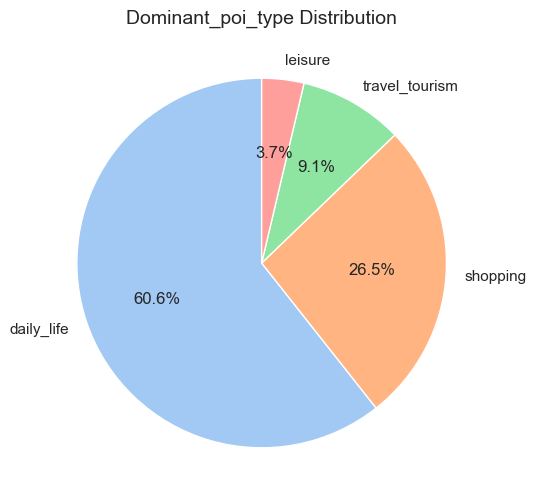

In [260]:
counts = poi_group_final_summary_df.dominant_poi_type.value_counts()

# Apply Seaborn theme
sns.set_theme(style="whitegrid")

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",   # show percentage
    startangle=90,       # rotate start
    colors=sns.color_palette("pastel")  # pretty colors
)

plt.title("Dominant_poi_type Distribution", fontsize=14)
plt.show()

In [262]:
station_df

,stationid,stationcode,stationstatus,name,address,zone,latitude,longitude,availableparking,province,locationgeometry,district,shapeID,geometry
0,1,X[CLOSED]-CENTRALWORLD,DISABLE,Central world,"999/9 Rama I Rd, แขวง ปทุมวัน เขต ปทุมวัน กรุง...",NaN,13.746790,100.537001,0,Bangkok,POINT (100.537 13.74679),Pathum Wan,78962969B24986508007859,"POLYGON ((100.54475 13.72617, 100.51569 13.738..."
1,2,ALL-SEASON,SERVICE,All Seasons Place,"87,ถนน วิทยุ,แขวง ลุมพินี เขต ปทุมวัน,กรุงเทพม...",NaN,13.739625,100.545313,0,Bangkok,POINT (100.54531 13.73962),Pathum Wan,78962969B24986508007859,"POLYGON ((100.54475 13.72617, 100.51569 13.738..."
2,3,KMUTT,SERVICE,KMUTT Bang Mod Campus,126 ถนน ประชาอุทิศ แขวง บางมด เขต ทุ่งครุ กรุง...,THUNG KHRU,13.651627,100.495427,2,Bangkok,POINT (100.49543 13.65163),Thung Khru,78962969B48707733075976,"POLYGON ((100.47693 13.60296, 100.47958 13.606..."
3,4,X[CLOSED]-INSANE,SERVICE,Insane Intelligence,27/9 พฤกษาวิล 27 ถนนสามวา แขวงมีนบุรี เขตมีนบุ...,คันนายาว,13.824903,100.682895,100,Bangkok,POINT (100.68289 13.8249),Khan Na Yao,78962969B51351558142585,"POLYGON ((100.64599 13.84737, 100.64815 13.847..."
4,5,X[CLOSED]-METROWESTTOWN,DISABLE,Metro West Town,"134 Kalapaphuk, ฺBangwa, Phasi Charoen, Bangko...",NaN,13.709391,100.449953,0,Bangkok,POINT (100.44995 13.70939),Phasi Charoen,78962969B24631471480950,"POLYGON ((100.43773 13.69368, 100.42782 13.687..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1238,2711,CHAIYAPHUM-DISTRICT-OFFICE,SERVICE,Chaiyaphum District Office,NaN,CHAIYAPHUM,15.809834,102.020336,1,Chaiyaphum,POINT (102.02034 15.80983),Mueang Chaiyaphum,78962969B81450935958728,"POLYGON ((101.97925 15.69032, 101.98186 15.695..."
1239,2712,CENTRAL-AYUTTHAYA,SERVICE,Central Ayutthaya,NaN,AYUTTHAYA,14.331531,100.611863,1,Phra Nakhon Si Ayutthaya,POINT (100.61186 14.33153),Phra Nakhon Si Ayutthaya,78962969B15942215938926,"POLYGON ((100.50824 14.32549, 100.51199 14.327..."
1240,2713,SUKSAWAT-64,DISABLE,Suksawat 64,NaN,KHET RAT BURANA,13.647051,100.516000,1,Bangkok,POINT (100.516 13.64705),Thung Khru,78962969B48707733075976,"POLYGON ((100.47693 13.60296, 100.47958 13.606..."
1241,2714,SUKSAWAT-64,SERVICE,Suksawat 64,NaN,KHET RAT BURANA,13.647051,100.516000,1,Bangkok,POINT (100.516 13.64705),Thung Khru,78962969B48707733075976,"POLYGON ((100.47693 13.60296, 100.47958 13.606..."


In [261]:
poi_group_final_summary_df

,stationid,poi_cnt_daily_life,poi_cnt_shopping,poi_cnt_leisure,poi_cnt_travel_tourism,sum_poi,perc_poi_cnt_daily_life,perc_poi_cnt_shopping,perc_poi_cnt_leisure,perc_poi_cnt_travel_tourism,dominant_poi_type
0,2,39,43,25,29,136,0.2868,0.3162,0.1838,0.2132,shopping
1,50,33,50,10,22,115,0.2870,0.4348,0.0870,0.1913,shopping
2,258,50,59,8,43,160,0.3125,0.3688,0.0500,0.2688,shopping
3,459,29,32,16,20,97,0.2990,0.3299,0.1649,0.2062,shopping
4,637,25,23,17,10,75,0.3333,0.3067,0.2267,0.1333,daily_life
...,...,...,...,...,...,...,...,...,...,...,...
0,2641,0,1,0,0,1,0.0000,1.0000,0.0000,0.0000,shopping
0,2652,1,0,0,0,1,1.0000,0.0000,0.0000,0.0000,daily_life
0,2663,1,0,0,0,1,1.0000,0.0000,0.0000,0.0000,daily_life
0,2679,3,4,0,2,9,0.3333,0.4444,0.0000,0.2222,shopping


## Reservation

In [68]:
reservation_df = pd.read_csv('../data/reservation_coop.csv')
reservation_df["reservationno"] = reservation_df["reservationno"].astype(object)
pd.set_option('display.max_columns', None)
str_columns = [
    'reservationno',
    'reservationstate',
    'userid',
    'usertype',
    'groupid',
    'owner_userid',
    'payment',
    'vehicleid',
    'stationid',
    'promotionid',
    'promotioncode',
    'chargetotal',
    'category']
date_columns = [
    'logtime', 
    'reservestarttime',
    'reservestoptime',
    'actualstarttime', 
    'actualstoptime', 
    'completetime',
]
float_columns = [
    'startkm', 
    'stopkm', 
    'reservehours', 
    'actualhours', 
    'hourprice', 
    'distance_price',
    'discount',
    'totalprice',
    'chargetotal'
]
for col in reservation_df.columns:
    if col in str_columns:
        reservation_df[col] = reservation_df[col].astype(object)
    elif col in date_columns:
        reservation_df[col] = pd.to_datetime(reservation_df[col], errors="coerce")
    elif col in float_columns:
        reservation_df[col] = pd.to_numeric(reservation_df[col], errors="coerce")


reservation_df.info()
reservation_df.head()

/var/folders/cj/gfy7l4ys0m7gd6jgx2hnycl40000gn/T/ipykernel_11253/2131227649.py:1: DtypeWarning:

Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129124 entries, 0 to 129123
Data columns (total 27 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   reservationno     129124 non-null  object        
 1   reservationstate  129124 non-null  object        
 2   logtime           129124 non-null  datetime64[ns]
 3   userid            129124 non-null  object        
 4   usertype          71166 non-null   object        
 5   groupid           129124 non-null  object        
 6   owner_userid      129124 non-null  object        
 7   payment           129124 non-null  object        
 8   vehicleid         129124 non-null  object        
 9   stationid         129124 non-null  object        
 10  promotionid       129124 non-null  object        
 11  promotioncode     29622 non-null   object        
 12  startkm           129124 non-null  float64       
 13  stopkm            129124 non-null  float64       
 14  rese

,reservationno,reservationstate,logtime,userid,usertype,groupid,owner_userid,payment,vehicleid,stationid,promotionid,promotioncode,startkm,stopkm,reservestarttime,reservestoptime,actualstarttime,actualstoptime,completetime,reservehours,actualhours,hourprice,distance_price,discount,totalprice,chargetotal,category
0,5,COMPLETE,2016-06-16 16:12:02,1,NaN,0,0,CASH,1,0,0,NaN,4946.338181,4946.338181,2016-01-01,2016-01-02,2016-01-01,2016-01-02,2017-08-29 12:03:09,24.0,24.0,4800.0,0.0,0.0,4800.0,0.0,NaN
1,6,COMPLETE,2016-06-16 16:15:50,1,NaN,0,0,CASH,1,0,0,NaN,0.000000,0.000000,2016-01-01,2016-01-02,NaT,NaT,NaT,24.0,0.0,4800.0,0.0,0.0,0.0,0.0,NaN
2,7,COMPLETE,2016-06-16 16:17:22,1,NaN,0,0,CASH,1,0,0,NaN,0.000000,0.000000,2016-01-01,2016-01-02,NaT,NaT,NaT,24.0,0.0,4800.0,0.0,0.0,0.0,0.0,NaN
3,8,COMPLETE,2016-06-16 16:22:28,1,NaN,0,0,CASH,1,0,0,NaN,0.000000,0.000000,2016-01-01,2016-01-02,NaT,NaT,NaT,24.0,0.0,4800.0,0.0,0.0,0.0,0.0,NaN
4,9,COMPLETE,2016-06-16 16:23:15,1,NaN,0,0,CASH,1,0,0,NaN,0.000000,0.000000,2016-01-01,2016-01-02,NaT,NaT,NaT,24.0,0.0,4800.0,0.0,0.0,0.0,0.0,NaN


In [77]:
reservation_df.isna().sum()

reservationno           0
reservationstate        0
logtime                 0
userid                  0
usertype            57958
groupid                 0
owner_userid            0
payment                 0
vehicleid               0
stationid               0
promotionid             0
promotioncode       99502
startkm                 0
stopkm                  0
reservestarttime        0
reservestoptime         0
actualstarttime     28121
actualstoptime      28306
completetime        29757
reservehours            0
actualhours             0
hourprice               0
distance_price          0
discount                0
totalprice              0
chargetotal             0
category            92802
dtype: int64

In [68]:
reservation_df[~reservation_df["category"].isna()]["category"].value_counts()

category
MA                   18552
HAUP                 12326
EXTERNAL              3424
MA,EXTERNAL            779
BATCH                  710
EXTERNAL,MA            211
LONGTERM               118
HAUP,MA                 68
INSTANT                 40
HAUP,LONGTERM           39
HAUP,EXTERNAL           37
,EXTERNAL               10
HAUP,EXTERNAL,MA         3
EXTERNAL,LONGTERM        2
MA,LONGTERM              1
HAUP,MA,INSTANT          1
HAUP,INSTANT             1
Name: count, dtype: int64

In [77]:
reservation_df[reservation_df['groupid'].isin([1,356])]['groupid'].value_counts()

groupid
1      4165
356       1
Name: count, dtype: int64

In [78]:
reservation_df = reservation_df[~reservation_df['groupid'].isin([1,356])]

### reservationstate

In [80]:
reservation_df['reservationstate'].value_counts()

reservationstate
COMPLETE    99691
REJECT      16291
CANCEL      11522
FINISH       1063
RESERVE       303
DRIVE         252
REQUEST         2
Name: count, dtype: int64

### logtime and reservestarttime

<Axes: xlabel='logtime', ylabel='Count'>

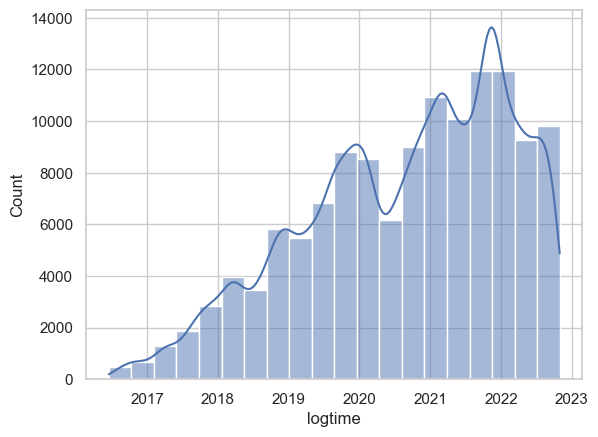

In [93]:
sns.histplot(reservation_df["logtime"],
    bins=20,
    kde=True
)

In [90]:
reservation_df[["logtime","reservestarttime","reservestoptime","actualstarttime","actualstoptime"]]

,logtime,reservestarttime,reservestoptime,actualstarttime,actualstoptime
0,2016-06-16 16:12:02,2016-01-01 00:00:00,2016-01-02 00:00:00,2016-01-01 00:00:00,2016-01-02
1,2016-06-16 16:15:50,2016-01-01 00:00:00,2016-01-02 00:00:00,NaT,NaT
2,2016-06-16 16:17:22,2016-01-01 00:00:00,2016-01-02 00:00:00,NaT,NaT
3,2016-06-16 16:22:28,2016-01-01 00:00:00,2016-01-02 00:00:00,NaT,NaT
4,2016-06-16 16:23:15,2016-01-01 00:00:00,2016-01-02 00:00:00,NaT,NaT
...,...,...,...,...,...
129119,2022-10-31 00:13:08,2022-11-03 08:00:00,2022-11-03 20:00:00,NaT,NaT
129120,2022-10-31 00:13:17,2022-11-04 08:00:00,2022-11-04 20:00:00,NaT,NaT
129121,2022-10-31 00:13:44,2022-11-03 08:00:00,2022-11-03 20:00:00,NaT,NaT
129122,2022-10-31 00:13:52,2022-11-04 08:00:00,2022-11-04 20:00:00,NaT,NaT


In [93]:
reservation_df[reservation_df["logtime"] > reservation_df["reservestarttime"]][["logtime","reservestarttime","reservestoptime"]]

,logtime,reservestarttime,reservestoptime
0,2016-06-16 16:12:02,2016-01-01 00:00:00,2016-01-02 00:00:00
1,2016-06-16 16:15:50,2016-01-01 00:00:00,2016-01-02 00:00:00
2,2016-06-16 16:17:22,2016-01-01 00:00:00,2016-01-02 00:00:00
3,2016-06-16 16:22:28,2016-01-01 00:00:00,2016-01-02 00:00:00
4,2016-06-16 16:23:15,2016-01-01 00:00:00,2016-01-02 00:00:00
...,...,...,...
129015,2022-10-30 12:00:52,2022-10-30 12:00:00,2022-10-30 22:30:00
129016,2022-10-30 12:03:00,2022-10-30 12:00:00,2022-10-30 23:00:00
129023,2022-10-30 14:06:37,2022-10-30 13:00:00,2022-10-30 18:00:00
129025,2022-10-30 15:00:46,2022-10-30 15:00:00,2022-10-30 15:35:00


time_diff

In [135]:
time_df = reservation_df.copy()

In [184]:
time_df["time_diff"] = (time_df['reservestarttime'] - time_df['logtime']).dt.total_seconds() / 3600
time_df[["time_diff","reservestarttime","logtime"]]

,time_diff,reservestarttime,logtime
0,-4024.200556,2016-01-01 00:00:00,2016-06-16 16:12:02
1,-4024.263889,2016-01-01 00:00:00,2016-06-16 16:15:50
2,-4024.289444,2016-01-01 00:00:00,2016-06-16 16:17:22
3,-4024.374444,2016-01-01 00:00:00,2016-06-16 16:22:28
4,-4024.387500,2016-01-01 00:00:00,2016-06-16 16:23:15
...,...,...,...
129119,79.781111,2022-11-03 08:00:00,2022-10-31 00:13:08
129120,103.778611,2022-11-04 08:00:00,2022-10-31 00:13:17
129121,79.771111,2022-11-03 08:00:00,2022-10-31 00:13:44
129122,103.768889,2022-11-04 08:00:00,2022-10-31 00:13:52


In [126]:
Q1 = time_df["time_diff"].quantile(0.25)
Q3 = time_df["time_diff"].quantile(0.75)
IQR = Q3 - Q1

# Calculate bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Identify outliers
outliers = time_df[(time_df["time_diff"] < lower_bound) | (time_df["time_diff"] > upper_bound)]

Lower Bound: -70.67524305555555
Upper Bound: 118.09503472222222


In [134]:
time_df_positive = time_df[time_df["time_diff"] > 0]
time_df_minus = time_df[time_df["time_diff"] < 0]

In [126]:
## minus
Q1 = time_df_minus["time_diff"].quantile(0.25)
Q3 = time_df_minus["time_diff"].quantile(0.75)
IQR = Q3 - Q1

# Calculate bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Identify outliers
outliers = time_df_minus[(time_df_minus["time_diff"] < lower_bound) | (time_df_minus["time_diff"] > upper_bound)]

Lower Bound: -1.2368055555555555
Upper Bound: 0.6754166666666667


In [134]:
time_df_minus[time_df_minus["time_diff"]< -0.5]["time_diff"].count()

reservationno       3671
reservationstate    3671
logtime             3671
userid              3671
usertype            1835
groupid             3671
owner_userid        3671
payment             3671
vehicleid           3671
stationid           3671
promotionid         3671
promotioncode         25
startkm             3671
stopkm              3671
reservestarttime    3671
reservestoptime     3671
actualstarttime     3315
actualstoptime      3356
completetime        3279
reservehours        3671
actualhours         3671
hourprice           3671
distance_price      3671
discount            3671
totalprice          3671
chargetotal         3671
category            2128
time_diff           3671
dtype: int64

In [142]:
## positive
time_df_positive["time_diff"].count()
Q1 = time_df_positive["time_diff"].quantile(0.25)
Q3 = time_df_positive["time_diff"].quantile(0.75)
IQR = Q3 - Q1

# Calculate bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Identify outliers
outliers = time_df_positive[(time_df_positive["time_diff"] < lower_bound) | (time_df_positive["time_diff"] > upper_bound)]

Lower Bound: -96.94395833333331
Upper Bound: 162.31326388888886


<Axes: xlabel='time_diff', ylabel='Count'>

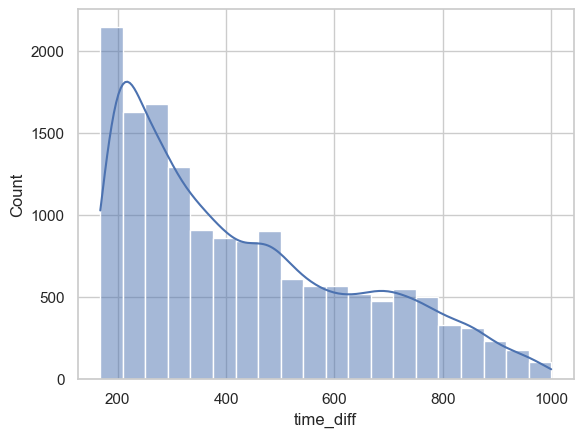

In [151]:
sns.histplot(time_df_positive[(time_df_positive["time_diff"]>168)&(time_df_positive["time_diff"]<1000)]["time_diff"],
    bins=20,
    kde=True
)

In [159]:
time_df_positive[time_df_positive["time_diff"]>720].count()

reservationno       3037
reservationstate    3037
logtime             3037
userid              3037
usertype            2626
groupid             3037
owner_userid        3037
payment             3037
vehicleid           3037
stationid           3037
promotionid         3037
promotioncode        196
startkm             3037
stopkm              3037
reservestarttime    3037
reservestoptime     3037
actualstarttime     2155
actualstoptime      2134
completetime        2126
reservehours        3037
actualhours         3037
hourprice           3037
distance_price      3037
discount            3037
totalprice          3037
chargetotal         3037
category            1135
time_diff           3037
dtype: int64

In [148]:
time_df_positive[time_df_positive["time_diff"]>upper_bound][['logtime','reservestarttime']]

,logtime,reservestarttime
927,2016-12-26 15:27:22,2017-01-06 11:30:00
1520,2017-03-21 09:03:55,2017-03-29 10:00:00
1554,2017-03-23 22:57:29,2017-03-30 23:00:00
1555,2017-03-23 23:05:04,2017-03-30 23:00:00
1556,2017-03-23 23:05:48,2017-03-30 23:00:00
...,...,...
128875,2022-10-29 21:12:51,2022-11-06 21:40:00
128877,2022-10-29 21:22:29,2022-12-03 08:00:00
128878,2022-10-29 21:23:44,2022-11-15 19:00:00
129018,2022-10-30 12:24:47,2022-12-09 00:00:00


In [185]:
time_df.loc[time_df["time_diff"] < 0.5, "time_diff"] = 0.5
time_df.loc[time_df["time_diff"] > 1000, "time_diff"] = 1000

<Axes: xlabel='time_diff', ylabel='Count'>

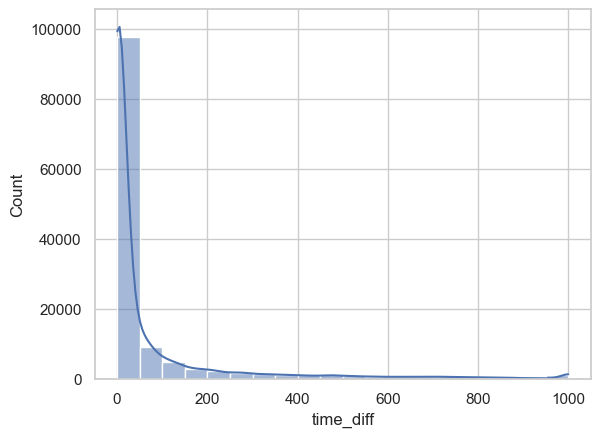

In [186]:
sns.histplot(time_df["time_diff"],
    bins=20,
    kde=True
)

Time diff lower bound = -0.5
Time diff upper bound = 720

### reservestarttime and reservestoptime

In [199]:
reservation_df[reservation_df["reservestarttime"] > reservation_df["reservestoptime"]]

,reservationno,reservationstate,logtime,userid,usertype,groupid,owner_userid,payment,vehicleid,stationid,promotionid,promotioncode,startkm,stopkm,reservestarttime,reservestoptime,actualstarttime,actualstoptime,completetime,reservehours,actualhours,hourprice,distance_price,discount,totalprice,chargetotal,category


reservehours

In [202]:
reservation_df[["reservestarttime","reservestoptime"]].isna().sum()

reservestarttime    0
reservestoptime     0
dtype: int64

In [204]:
reservation_df["reservehour"] = reservation_df["reservestoptime"] - reservation_df["reservestarttime"]

In [205]:
reservation_df

,reservationno,reservationstate,logtime,userid,usertype,groupid,owner_userid,payment,vehicleid,stationid,promotionid,promotioncode,startkm,stopkm,reservestarttime,reservestoptime,actualstarttime,actualstoptime,completetime,reservehours,actualhours,hourprice,distance_price,discount,totalprice,chargetotal,category,reservehour
0,5,COMPLETE,2016-06-16 16:12:02,1,NaN,0,0,CASH,1,0,0,NaN,4946.338181,4946.338181,2016-01-01 00:00:00,2016-01-02 00:00:00,2016-01-01 00:00:00,2016-01-02,2017-08-29 12:03:09,24.000000,24.0,4800.0,0.0,0.0,4800.0,0.0,NaN,1 days 00:00:00
1,6,COMPLETE,2016-06-16 16:15:50,1,NaN,0,0,CASH,1,0,0,NaN,0.000000,0.000000,2016-01-01 00:00:00,2016-01-02 00:00:00,NaT,NaT,NaT,24.000000,0.0,4800.0,0.0,0.0,0.0,0.0,NaN,1 days 00:00:00
2,7,COMPLETE,2016-06-16 16:17:22,1,NaN,0,0,CASH,1,0,0,NaN,0.000000,0.000000,2016-01-01 00:00:00,2016-01-02 00:00:00,NaT,NaT,NaT,24.000000,0.0,4800.0,0.0,0.0,0.0,0.0,NaN,1 days 00:00:00
3,8,COMPLETE,2016-06-16 16:22:28,1,NaN,0,0,CASH,1,0,0,NaN,0.000000,0.000000,2016-01-01 00:00:00,2016-01-02 00:00:00,NaT,NaT,NaT,24.000000,0.0,4800.0,0.0,0.0,0.0,0.0,NaN,1 days 00:00:00
4,9,COMPLETE,2016-06-16 16:23:15,1,NaN,0,0,CASH,1,0,0,NaN,0.000000,0.000000,2016-01-01 00:00:00,2016-01-02 00:00:00,NaT,NaT,NaT,24.000000,0.0,4800.0,0.0,0.0,0.0,0.0,NaN,1 days 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129119,185336,RESERVE,2022-10-31 00:13:08,296690,NaN,3,0,CASH,672,2696,0,NaN,0.000000,0.000000,2022-11-03 08:00:00,2022-11-03 20:00:00,NaT,NaT,NaT,12.000000,0.0,1280.0,0.0,0.0,190.0,0.0,HAUP,0 days 12:00:00
129120,185337,RESERVE,2022-10-31 00:13:17,296690,NaN,3,0,CASH,672,2696,0,NaN,0.000000,0.000000,2022-11-04 08:00:00,2022-11-04 20:00:00,NaT,NaT,NaT,12.000000,0.0,1280.0,0.0,0.0,190.0,0.0,HAUP,0 days 12:00:00
129121,185338,RESERVE,2022-10-31 00:13:44,296538,NaN,347,0,CASH,848,2698,0,NaN,0.000000,0.000000,2022-11-03 08:00:00,2022-11-03 20:00:00,NaT,NaT,NaT,12.000000,0.0,1280.0,0.0,0.0,190.0,0.0,HAUP,0 days 12:00:00
129122,185339,RESERVE,2022-10-31 00:13:52,296538,NaN,347,0,CASH,848,2698,0,NaN,0.000000,0.000000,2022-11-04 08:00:00,2022-11-04 20:00:00,NaT,NaT,NaT,12.000000,0.0,1280.0,0.0,0.0,190.0,0.0,HAUP,0 days 12:00:00


### promotioncode

In [84]:
reservation_df["promotioncode"].unique()

array([nan, 'fbshare', 'testpro', ..., '2GETHER', '1DCL', '1DCM'],
      shape=(1413,), dtype=object)